In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
base_path = '../../data/modelling/'

X_train = pd.read_csv(base_path + 'X_train.csv', index_col=0)
X_test = pd.read_csv(base_path + 'X_test.csv', index_col=0)
y_train = pd.read_csv(base_path + 'y_train.csv', index_col=0)['log_price']
y_test = pd.read_csv(base_path + 'y_test.csv', index_col=0)['log_price']

In [3]:
model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [4]:
y_pred = model.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 0.174678162347934
RMSE: 0.2473213293235481
R2: 0.839706805599312


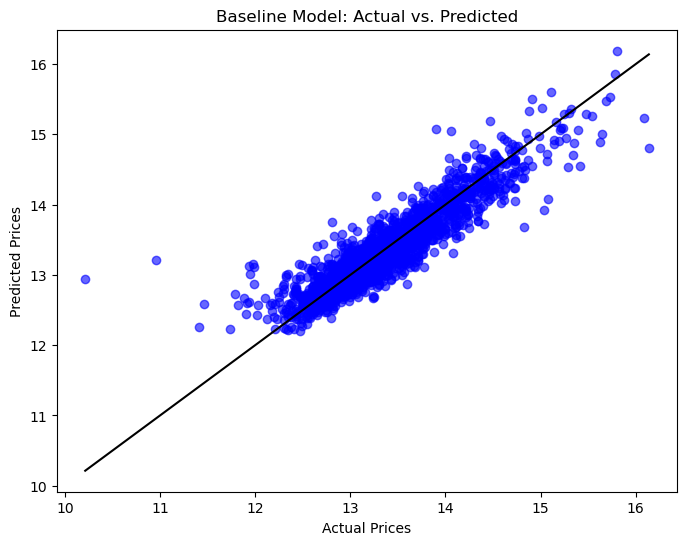

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Baseline Model: Actual vs. Predicted')
plt.show()

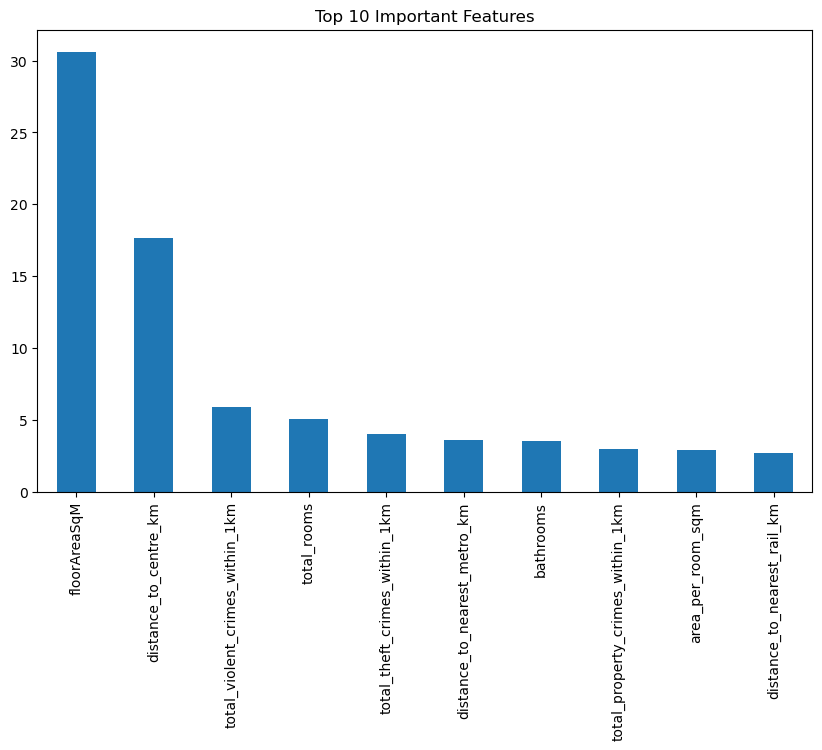

In [7]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

In [8]:
model_tuned = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=5,
    subsample=0.6,
    random_state=42,
    verbose=0
)

model_tuned.fit(X_train, y_train)

CatBoostRegressor(depth=8, iterations=1000, l2_leaf_reg=5, learning_rate=0.1, loss_function='RMSE', random_state=42, subsample=0.6, verbose=0)

In [9]:
y_pred_tuned = model_tuned.predict(X_test)

In [10]:
mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print('=== Baseline Model ===')
print('MAE:', mae_base)
print('RMSE:', rmse_base)
print('R2:', r2_base)

print('=== Tuned Model ===')
print('MAE:', mae_tuned)
print('RMSE:', rmse_tuned)
print('R2:', r2_tuned)

=== Baseline Model ===
MAE: 0.174678162347934
RMSE: 0.2473213293235481
R2: 0.839706805599312
=== Tuned Model ===
MAE: 0.1720839271202384
RMSE: 0.24412647991446743
R2: 0.8438213308819313


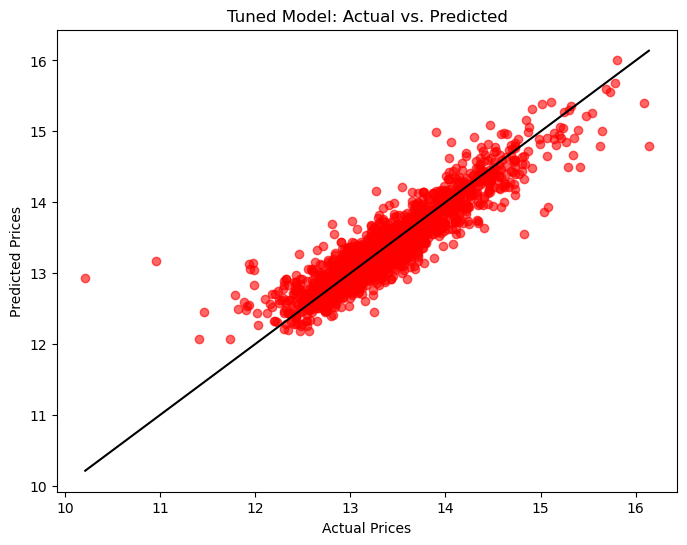

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tuned, alpha=0.6, color='red')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Tuned Model: Actual vs. Predicted')
plt.show()

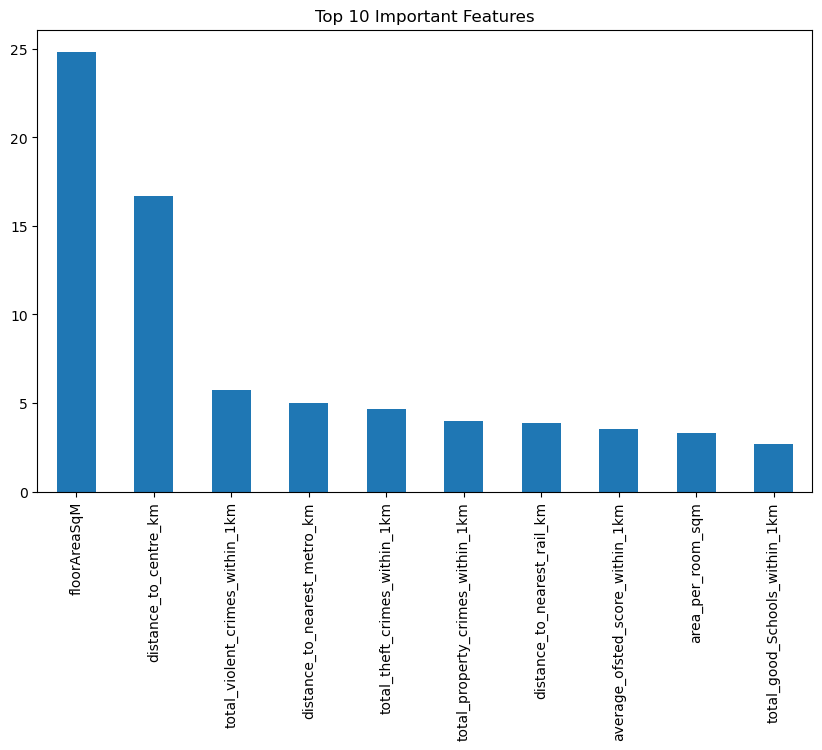

In [12]:
importance = pd.Series(model_tuned.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

In [13]:
joblib.dump(model_tuned, "../../models/property_price_predictor.pkl")

['../../models/property_price_predictor.pkl']

In [14]:
joblib.dump(X_train.columns.tolist(), "../../models/feature_columns.pkl")

['../../models/feature_columns.pkl']